# **MÓDULO 27 - Projeto de Doenças Cardiovasculares - Regressão Logística**


Assim como na aula que trabalhamos com uma base de dados nova, com um contexto de modelo de propensão a compra de carros, para a atividade de vocês achei interessante trazer também novos desafios.

Nessa tarefa iremos construir um modelo que nos ajude a prever doenças cardiovasculares, a base contém dados reais.

age - idade dos pacientes

gender - genero (2 mulheres) (1 homens)

height - altura dos pacientes

weight - peso dos pacientes

gluc - glicose

smoke - fumante (1) não fumante (0)

alco - consume alcool (1) não consome (0)

active - realiza atividades fisicas (1) não realiza (0)

cardio_disease - tem doença cardio (1) não tem (0) - Variável target


Seu objetivo é utilizar esses dados históricos dos pacientes e construir um bom modelo de regressão capaz de indicar se novos pacientes estão propensos a doenças cariovasculares ou não.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

# 1) Comece carregando e tratando a base de dados.
Assim como na aula essa nova base não passou por pré processamento nenhum então nessa etapa, carrega os dados, verifique os tipos de dados, verifique se temos dados faltantes e outliers.
Quando necessário realize o tratamento.


In [2]:
base = pd.read_csv("CARDIO_BASE.csv", delimiter=';')

In [8]:
# Retornando os dados iniciais da base
base.head(15)

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
0,50,2,168,62,1,1,0,0,1,0
1,55,1,156,85,3,1,0,0,1,1
2,52,1,165,64,3,1,0,0,0,1
3,48,2,169,82,1,1,0,0,1,1
4,48,1,156,56,1,1,0,0,0,0
5,60,1,151,67,2,2,0,0,0,0
6,61,1,157,93,3,1,0,0,1,0
7,62,2,178,95,3,3,0,0,1,1
8,48,1,158,71,1,1,0,0,1,0
9,54,1,164,68,1,1,0,0,0,0


In [5]:
# verificando informaçoes da base
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             10000 non-null  int64 
 1   gender          10000 non-null  int64 
 2   height          10000 non-null  int64 
 3   weight          10000 non-null  object
 4   cholesterol     10000 non-null  int64 
 5   gluc            10000 non-null  int64 
 6   smoke           10000 non-null  int64 
 7   alco            10000 non-null  int64 
 8   active          10000 non-null  int64 
 9   cardio_disease  10000 non-null  int64 
dtypes: int64(9), object(1)
memory usage: 781.4+ KB


In [10]:
# verificando dados unicos
# Agora que temos os Dtypes, vamos verificar os dados unicos que tem em cada coluna
colunas = base.columns
for i in colunas:

    print(f'Para a coluna {i}, temos os seguintes valores unicos {base[i].unique()}')
    print("=====================================")

Para a coluna age, temos os seguintes valores unicos [50 55 52 48 60 61 62 54 41 40 46 58 59 63 64 57 56 49 51 44 65 45 53 47
 42 39 43 30]
Para a coluna gender, temos os seguintes valores unicos [2 1]
Para a coluna height, temos os seguintes valores unicos [168 156 165 169 151 157 178 158 164 173 181 172 170 154 162 163 153 159
 166 155 160 175 171 152 187 148 179 180 188 185 167 183 174 176 161 184
 177 182  76 149 142 150 144 147 186 146 141 195 140 198 145 143 196 138
 194 190 134 136 100 120 189 137 192 122 250 191 117  70  97 119 130]
Para a coluna weight, temos os seguintes valores unicos ['62' '85' '64' '82' '56' '67' '93' '95' '71' '68' '80' '60' '78' '112'
 '75' '52' '83' '69' '90' '45' '65' '59' '66' '74' '105' '73' '55' '70'
 '72' '63' '50' '107' '84' '77' '79' '76' '58' '115' '97' '53' '57' '49'
 '110' '94' '92' '87' '103' '88' '99' '100' '61' '48' '54' '51' '47' '91'
 '104' '81' '98' '108' '89' '101' '86' '65,5' '142' '96' '44' '41' '169'
 '116' '200' '64,8' '120' '117' '

In [11]:
# Retornando estatisticas descritivas da base
base.describe()

,age,gender,height,cholesterol,gluc,smoke,alco,active,cardio_disease
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,53.288300,1.345400,164.308200,1.365000,1.222200,0.089000,0.053700,0.797200,0.503100
std,6.796234,0.475522,8.178796,0.677658,0.565561,0.284758,0.225436,0.402105,0.500015
min,30.000000,1.000000,70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,250.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


**Tratamentos necessários**

Avaliando os dados da base de pacientes, podemos notar alguns itens que precisam ser tratados 

- **1 -  Coluna “weight”**

A coluna está como tipo object, ela armazena os dados de peso dos pacientes e será melhor aproveitada se tiver sido aplicado o tipo float e mudando o separador de virgula para ponto.
Outro ponto positivo com essa mudança é retornar dados estatísticos mais apurados com relação a esta variável pelo método describe().

- **2 - Coluna “height”**

Pelas estatísticas da coluna, podemos verificar que existem alguns outliers com relação aos valores máximos e mínimos, a altura mínima está em 70 e a máxima 250. Fazendo uma busca pela OMS e o percentual de pessoas que apresentam a condição de nanismo, foi encontrado que cerca de 0,004% da população mundial tem essa condição e que pela OMS consiste em pessoas em fase adulta que apresentam altura inferior a 1,45m para homens e 1,40m para mulheres existe um percentual muito grande na amostra de pessoas com essas condições, o que podemos deduzir que forma erros de digitação. 
Neste caso, vamos remover essas informações para evitar dados discrepantes que podem trazer erros no modelo futuro.
Fonte: https://www.tre-ce.jus.br/comunicacao/noticias/2022/Fevereiro/serie-vamos-falar-sobre-aborda-o-tema-nanismo
https://bvsms.saude.gov.br/nanismo/
https://diariopcd.com.br/nanismo-acomete-250-mil-pessoas-no-mundo-no-brasil-estima-se-que-seja-1-para-cada-10-mil-habitantes/

O mesmo será feito para dados com altura maior que 2,10m
 
- **3 - Coluna “cholesterol”**

A coluna cholesterol, não está relacionada no glossário de definição dos dados, mas avaliando a origem da relação dos dados(https://www.kaggle.com/datasets/mdshamimrahman/cardio-data-set/data) .Os valores significam:

1: Colesterol normal

2: Colesterol acima do normal

3: Colesterol muito acima do normal


#### 1 -  Coluna “weight

In [ ]:
# Alterando o tipo da coluna weight

base['weight'] = base['weight'].str.replace(',', '.', regex=False).astype('float64')

# Validando mudança do tipo da coluna weight
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             10000 non-null  int64  
 1   gender          10000 non-null  int64  
 2   height          10000 non-null  int64  
 3   weight          10000 non-null  float64
 4   cholesterol     10000 non-null  int64  
 5   gluc            10000 non-null  int64  
 6   smoke           10000 non-null  int64  
 7   alco            10000 non-null  int64  
 8   active          10000 non-null  int64  
 9   cardio_disease  10000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 781.4 KB


In [13]:
# trasendo metricas descritivas da coluna weight
base['weight'].describe()

count    10000.000000
mean        74.303710
std         14.566353
min         30.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

#### 2 - Coluna "height"

In [15]:
# Antes de fazer a exclusão dos outliers, vamos analisar retornar os dados que serão excluidos

# Contando as linhas com altura menor que 145cm
linhas_menor_145 = base[base['height'] < 145]
count_menor_145 = len(linhas_menor_145)

# Contando as linhas com altura maior que 210cm
linhas_maior_210 = base[base['height'] > 210]
count_maior_210 = len(linhas_maior_210)

# total de linhas que serão excluidas
total_excluidas = count_menor_145 + count_maior_210

print(f"Número de linhas a serem removidas com 'height' menor que 145: {count_menor_145}")
print(f"Número de linhas a serem removidas com 'height' maior que 200: {count_maior_210}")
print(f"Total de linhas que serão removidas: {total_excluidas}, um percentual de {total_excluidas / len(base) * 100:.2f}% do total da base.")

Número de linhas a serem removidas com 'height' menor que 145: 46
Número de linhas a serem removidas com 'height' maior que 200: 1
Total de linhas que serão removidas: 47, um percentual de 0.47% do total da base.


In [16]:
# Removendo linhas com 'height' menor que 145 ou maior que 200
base_tratada = base[(base['height'] >= 145) & (base['height'] <= 210)]

# Exibindo o número de linhas antes e depois da filtragem para ver a diferença
print(f"Número de linhas antes: {len(base)}")
print(f"Número de linhas depois: {len(base_tratada)}")

Número de linhas antes: 10000
Número de linhas depois: 9953


In [17]:
# Avaliando os dados da base tratada
base_tratada.describe()

,age,gender,height,weight,cholesterol,gluc,smoke,alco,active,cardio_disease
count,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000,9953.000000
mean,53.288355,1.346026,164.450618,74.328655,1.365116,1.222445,0.089219,0.053954,0.796644,0.503064
std,6.792104,0.475726,7.754731,14.496103,0.677733,0.565940,0.285074,0.225937,0.402515,0.500016
min,30.000000,1.000000,145.000000,37.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,165.000000,72.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000
75%,58.000000,2.000000,170.000000,82.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,65.000000,2.000000,198.000000,200.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
base_tratada.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9953 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             9953 non-null   int64  
 1   gender          9953 non-null   int64  
 2   height          9953 non-null   int64  
 3   weight          9953 non-null   float64
 4   cholesterol     9953 non-null   int64  
 5   gluc            9953 non-null   int64  
 6   smoke           9953 non-null   int64  
 7   alco            9953 non-null   int64  
 8   active          9953 non-null   int64  
 9   cardio_disease  9953 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 855.3 KB


# 2) Agora é hora de explorar os dados com uma análise bem completa.
Plote pelo menos 3 gráficos analisando o comportamento da variável cardio com outras variaveis da sua preferência (análise bivariada). Não se esqueça de trazer insights acerca do analisado.


In [ ]:
# seu código aqui

# 3) Nessa etapa você deve trazer a matriz de correlação e apontar insights acerca das variáveis com um relacionamento mais forte entre si.



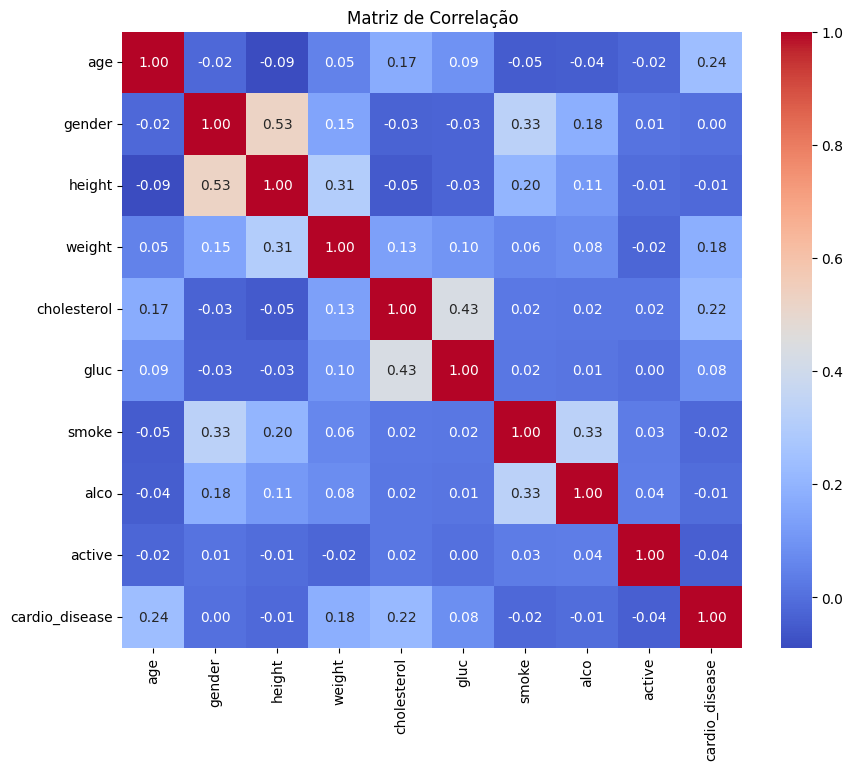

In [21]:
# seu código aqui
# Criando um mapa de calor para visualizar a matriz de correlação

correlation_matrix = base_tratada.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

# 4) Essa é a sua última etapa pré modelo. Você deve:

A) Separar a base em treino e teste.

B) Você considera que essa base precisa que os dados sejam padronizados? Se sim, porque? Se acredita que devem, então realize essa etapa.

C) Verifique se os dados estão balanceados, se não, faça o balanceamento.


D) Visualize as bases de treino, teste (X E Y) e verifique se está tudo adequado.

In [ ]:
# seu código aqui

# 5) Realize a etapa de treinamento do modelo:

A) Faça o treinamento do modelo.

B) Traga o intercept e os coeficientes.

c) Avalie as métricas do modelo treinado

D) Justifique se te parece que o modelo tem feito boas previsões ou não.

In [ ]:
# seu código aqui

# 6) Teste seu modelo!

A) Aplique o modelo aos dados de teste.

B) Avalie as métricas do modelo treinado

C) Plote o gráfico da curva AUC-ROC e explique o que consegue analisar através do gráfico.

In [ ]:
# seu código aqui

# 7) Explique:

A) Explique com suas palavras regressão logistica.

B) Explique porque a regressão logistica é um modelo de classificação.

C) Explique quais pontos em comum a regressão logistica tem da regressão linear.



In [ ]:
# seu código aqui